# Émulation d'une démarche comparative multi-algorithmes

Ce notebook illustre comment émuler une démarche d'analyse comparative de plusieurs algorithmes sur des problèmes d'optimisation, en Python.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
def parse_csv_file(filepath):
    df = pd.read_csv(filepath)
    return {
        'evals': df['evaluation'].values,
        'best': df['best_fitness'].values
    }

def compute_median(runs):
    max_eval = max(r['evals'][-1] for r in runs)
    min_eval = min(r['evals'][0] for r in runs)
    grid = np.logspace(np.log10(min_eval), np.log10(max_eval), 300)
    matrix = []
    for r in runs:
        values = []
        for g in grid:
            i = np.searchsorted(r['evals'], g) - 1
            values.append(r['best'][i] if i >= 0 else np.nan)
        matrix.append(values)
    matrix = np.array(matrix)
    return grid, np.nanmedian(matrix, axis=0), np.nanpercentile(matrix, 25, axis=0), np.nanpercentile(matrix, 75, axis=0)


C:\Users\driss\AppData\Local\Temp\ipykernel_18228\2268300502.py:20: RuntimeWarning: All-NaN slice encountered
  return grid, np.nanmedian(matrix, axis=0), np.nanpercentile(matrix, 25, axis=0), np.nanpercentile(matrix, 75, axis=0)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
C:\Users\driss\AppData\Local\Temp\ipykernel_18228\2268300502.py:20: RuntimeWarning: All-NaN slice encountered
  return grid, np.nanmedian(matrix, axis=0), np.nanpercentile(matrix, 25, axis=0), np.nanpercentile(matrix, 75, axis=0)
c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
C:\Users\driss\AppData\Local\Temp\ipykernel_18228\2268300502.py:20: RuntimeWarning: All-NaN slice encountered
  return grid, np.nanmedian(matrix, axis=0), np.nanpercentile(matrix, 25, axis=0), np.nanpercentile(matrix, 75, axis=0)
c:\Pro

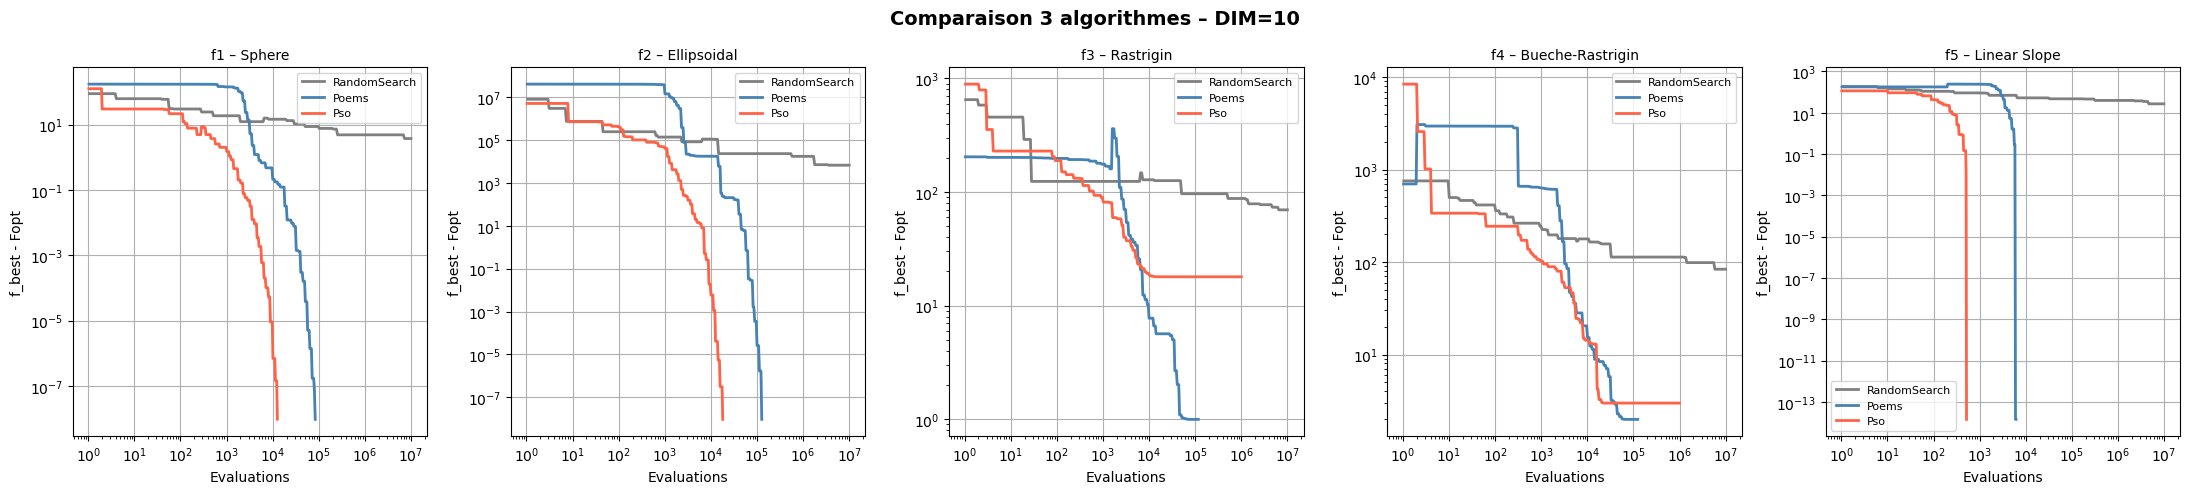

In [ ]:
ALGOS = {
    'RandomSearch': 'Etape3_csv/RandomSearch',
    'Poems': 'Etape3_csv/Poems',
    'Pso': 'Etape3_csv/Pso',
}

PROBLEMS = {
    1: 'f1 – Sphere',
    2: 'f2 – Ellipsoidal',
    3: 'f3 – Rastrigin',
    4: 'f4 – Bueche-Rastrigin',
    5: 'f5 – Linear Slope',
}
DIM = 10
COLORS = {
    'RandomSearch': 'gray',
    'Poems': 'steelblue',
    'Pso': 'tomato',
}

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)
fig.suptitle(f'Comparaison 3 algorithmes – DIM={DIM}', fontsize=14, fontweight='bold')

for ax, (fid, fname) in zip(axes, PROBLEMS.items()):
    for algo_name, algo_path in ALGOS.items():
        filepath = os.path.join(algo_path, f'bbobexp_f{fid}_DIM{DIM}.csv')
        if not os.path.exists(filepath):
            print(f'Fichier manquant : {filepath}')
            continue
        run = parse_csv_file(filepath)
        runs = [run]
        grid, med, q25, q75 = compute_median(runs)
        valid = (med > 0) & ~np.isnan(med)
        color = COLORS[algo_name]
        ax.plot(grid[valid], med[valid], color=color, lw=2, label=algo_name)
        ax.fill_between(grid[valid], q25[valid], q75[valid], color=color, alpha=0.15)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(fname, fontsize=10)
    ax.set_xlabel('Evaluations')
    ax.set_ylabel('f_best - Fopt')
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Analyser les résultats obtenus

On analyse les courbes obtenues pour comparer la rapidité de convergence, la robustesse et la performance finale de chaque algorithme sur chaque problème.

- Une courbe qui descend rapidement et se stabilise bas indique une bonne convergence.
- Si la zone colorée (IQR) est étroite, l’algorithme est stable sur ce problème.
- Comparez la performance finale (valeur la plus basse atteinte) entre les algorithmes.
- Repérez les problèmes où un algorithme surpasse systématiquement les autres ou, au contraire, échoue à converger.

##  Comparaison quantitative des algorithmes


In [ ]:
stats_path = 'Etape3_results/comparative_stats.csv'
if os.path.exists(stats_path):
    stats_df = pd.read_csv(stats_path)
    display(stats_df)
    #meilleur algo par problème (moyenne la plus basse)
    print('Meilleur algorithme par problème (fitness moyenne la plus basse) :')
    for problem in stats_df['problem'].unique():
        sub = stats_df[stats_df['problem'] == problem]
        best = sub.loc[sub['mean'].idxmin()]
        print(f"{problem}: {best['algo']} (mean={best['mean']:.2g})")
else:
    print('Fichier comparative_stats.csv non trouvé. Exécutez analyse_multi_algo.py pour le générer.')

,algo,problem,mean,median,std,min,max
0,Poems,bbobexp_f1_DIM10.csv,9.325682e+01,1.062625e+02,7.193312e+01,8.619807e-10,2.139499e+02
1,Pso,bbobexp_f1_DIM10.csv,5.984721e+01,3.288219e+01,6.743852e+01,5.517748e-09,3.339703e+02
2,RandomSearch,bbobexp_f1_DIM10.csv,1.439504e+02,1.391185e+02,5.549820e+01,2.155751e+01,3.767302e+02
3,Poems,bbobexp_f2_DIM10.csv,8.532860e+06,2.217737e+06,1.186207e+07,6.165521e-09,4.060373e+07
4,Pso,bbobexp_f2_DIM10.csv,6.290288e+06,1.288469e+06,1.142218e+07,5.068017e-09,7.294703e+07
5,RandomSearch,bbobexp_f2_DIM10.csv,1.818285e+07,1.271202e+07,1.669445e+07,8.151391e+04,7.768315e+07
6,Poems,bbobexp_f3_DIM10.csv,6.793605e+02,2.616055e+02,1.181920e+03,2.377448e-09,4.792797e+03
7,Pso,bbobexp_f3_DIM10.csv,4.639149e+02,1.275901e+02,1.083857e+03,9.519255e-09,9.775703e+03
8,RandomSearch,bbobexp_f3_DIM10.csv,1.592083e+03,8.745379e+02,1.762043e+03,1.668167e+02,9.756892e+03
9,Poems,bbobexp_f4_DIM10.csv,9.920789e+02,6.025203e+02,1.406160e+03,5.594131e-09,5.477610e+03


Meilleur algorithme par problème (fitness moyenne la plus basse) :
bbobexp_f1_DIM10.csv: Pso (mean=60)
bbobexp_f2_DIM10.csv: Pso (mean=6.3e+06)
bbobexp_f3_DIM10.csv: Pso (mean=4.6e+02)
bbobexp_f4_DIM10.csv: Pso (mean=9.8e+02)
bbobexp_f5_DIM10.csv: Pso (mean=1.4e+02)
